<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-5---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Entregable_Tarea_5_2_Alfaro_Badillo_Cruz_Perez_Rupit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contaminación Atmosférica y Calidad del Aire (PM2.5)

## Modelos Base y Regularización

Rúbrica: 20% Implementación correcta de Regresión Logística/GLM. Interpretación de coeficientes y justificación analítica del efecto de las penalizaciones Lasso y Ridge en su matriz de datos.


## Resumen de la programación realizada en este código
Se genera una visualización, así como las correlaciones de las diferentes variables para poder identificar posibles colinealidades.
1) Cálculo de correlaciones y Visualización de datos en
2)
3)

In [ ]:
# necesito saber que tan independientes o dependientes son mis variables entre si.
# Para ello necesito visualizar posibles correlaciones o relaciones estadisticas entre ellas.

# Dadas las graficas de abajo quiero diferenciar que variables son dependientes de otras, y ver como esto afecta al tipo de imputacion
# despues, normalizamos

In [1]:
# Incluir librerías necesarias para procesamiento y graficación
import pandas as pd # Manejo de datos en tablas
import numpy as np # Operaciones numéricas
import matplotlib.pyplot as plt  # Gráficas
import seaborn as sns  # Gráficas más avanzadas
#from sklearn.experimental import enable_iterative_imputer
#from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
#from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
#from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Modelo en la base de datos PRSA_data_clean_scaled

In [2]:
# Importar la información  ya limpia y normalizada
df_clean = pd.read_csv("PRSA_data_clean_scaled.csv", sep='\t', encoding='utf-8')

In [3]:
display(df_clean.head(3))

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_DIRECTION,...,WIND_SPEED_lag5_scaled,WIND_SPEED_lag9_scaled,WIND_SPEED_lag13_scaled,WIND_SPEED_lag17_scaled,WIND_SPEED_lag21_scaled,WIND_SPEED_lag25_scaled,hour_sin_scaled,hour_cos_scaled,month_sin_scaled,month_cos_scaled
0,26,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,...,-0.464615,-0.446867,0.284782,0.011501,-0.216852,-0.443743,0.366439,1.365439,0.707518,1.220224
1,27,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,...,-0.446343,-0.428703,0.348794,0.075645,-0.152795,-0.380073,0.707398,1.224107,0.707518,1.220224
2,28,2010,1,2,3,181.0,-7,-5.0,1022.0,SE,...,-0.428273,-0.446867,0.412807,0.158028,-0.088738,-0.343661,1.000186,0.999281,0.707518,1.220224


In [4]:
# Me doy cuenta que la columna FECHA y FECHA_SIN_H están como objetos y no como dates
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41756 entries, 0 to 41755
Data columns (total 90 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   NO                       41756 non-null  int64  
 1   YEAR                     41756 non-null  int64  
 2   MONTH                    41756 non-null  int64  
 3   DAY                      41756 non-null  int64  
 4   HOUR                     41756 non-null  int64  
 5   PM25                     41756 non-null  float64
 6   DEWPOINT                 41756 non-null  int64  
 7   TEMP                     41756 non-null  float64
 8   PRESION                  41756 non-null  float64
 9   WIND_DIRECTION           41756 non-null  object 
 10  WIND_SPEED               41756 non-null  float64
 11  SNOW                     41756 non-null  int64  
 12  RAIN                     41756 non-null  int64  
 13  FECHA                    41756 non-null  object 
 14  FECHA_SIN_H           

In [5]:
# Se transforman las columnas de fechas a formato date.
df_clean["FECHA"] = pd.to_datetime(df_clean["FECHA"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
df_clean["FECHA_SIN_H"] = pd.to_datetime(df_clean["FECHA_SIN_H"], format="%Y-%m-%d", errors="coerce")


In [6]:
df_clean.drop(columns=["NO", "YEAR", "MONTH", "DAY", "HOUR","FECHA", "FECHA_SIN_H" ]).describe()

,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,...,WIND_SPEED_lag5_scaled,WIND_SPEED_lag9_scaled,WIND_SPEED_lag13_scaled,WIND_SPEED_lag17_scaled,WIND_SPEED_lag21_scaled,WIND_SPEED_lag25_scaled,hour_sin_scaled,hour_cos_scaled,month_sin_scaled,month_cos_scaled
count,41756.000000,41756.000000,41756.000000,41756.000000,41756.000000,41756.000000,41756.000000,41756.000000,41756.000000,41756.000000,...,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04
mean,98.612487,1.750599,12.401954,1016.442811,23.867276,0.055345,0.194870,0.113900,0.322924,0.348980,...,-6.534352e-17,5.173029e-17,1.565522e-16,4.628499e-17,1.361323e-17,6.398220e-17,-2.339775e-17,5.036896e-17,8.848602e-18,6.534352e-17
std,92.051369,14.433570,12.175096,10.300841,49.617972,0.778884,1.418182,0.317693,0.467599,0.476653,...,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-4.735485e-01,-4.742138e-01,-4.741636e-01,-4.741910e-01,-4.730815e-01,-4.710011e-01,-1.413161e+00,-1.415801e+00,-1.422073e+00,-1.408571e+00
25%,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-4.463429e-01,-4.468668e-01,-4.467589e-01,-4.467300e-01,-4.456576e-01,-4.437429e-01,-9.990964e-01,-1.001439e+00,-7.122095e-01,-1.219832e+00
50%,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-3.736590e-01,-3.738054e-01,-3.735435e-01,-3.733639e-01,-3.723908e-01,-3.711222e-01,5.447026e-04,-1.078595e-03,-2.345648e-03,1.962625e-04
75%,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000,0.000000,1.000000,1.000000,...,-3.785166e-02,-3.645763e-02,-3.548448e-02,-3.460941e-02,-3.409450e-02,-3.466679e-02,1.000186e+00,9.992814e-01,7.075182e-01,1.220224e+00
max,994.000000,28.000000,42.000000,1046.000000,565.490000,27.000000,36.000000,1.000000,1.000000,1.000000,...,1.020874e+01,9.524381e+00,9.545512e+00,9.566099e+00,1.150236e+01,1.143208e+01,1.414251e+00,1.413644e+00,1.417382e+00,1.408963e+00


DEWPOINT                  0.171436
DEWPOINT_scaled           0.171436
DEWPOINT_lag1             0.169045
DEWPOINT_lag1_scaled      0.169045
WIND_DIRECTION_cv         0.156200
                            ...   
WIND_SPEED_lag5          -0.232563
WIND_SPEED_scaled        -0.247782
WIND_SPEED               -0.247782
WIND_SPEED_lag1          -0.247817
WIND_SPEED_lag1_scaled   -0.247817
Name: PM25, Length: 85, dtype: float64


/tmp/ipykernel_19897/845714348.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_pm25_sorted.values, y=corr_pm25_sorted.index, palette="coolwarm")


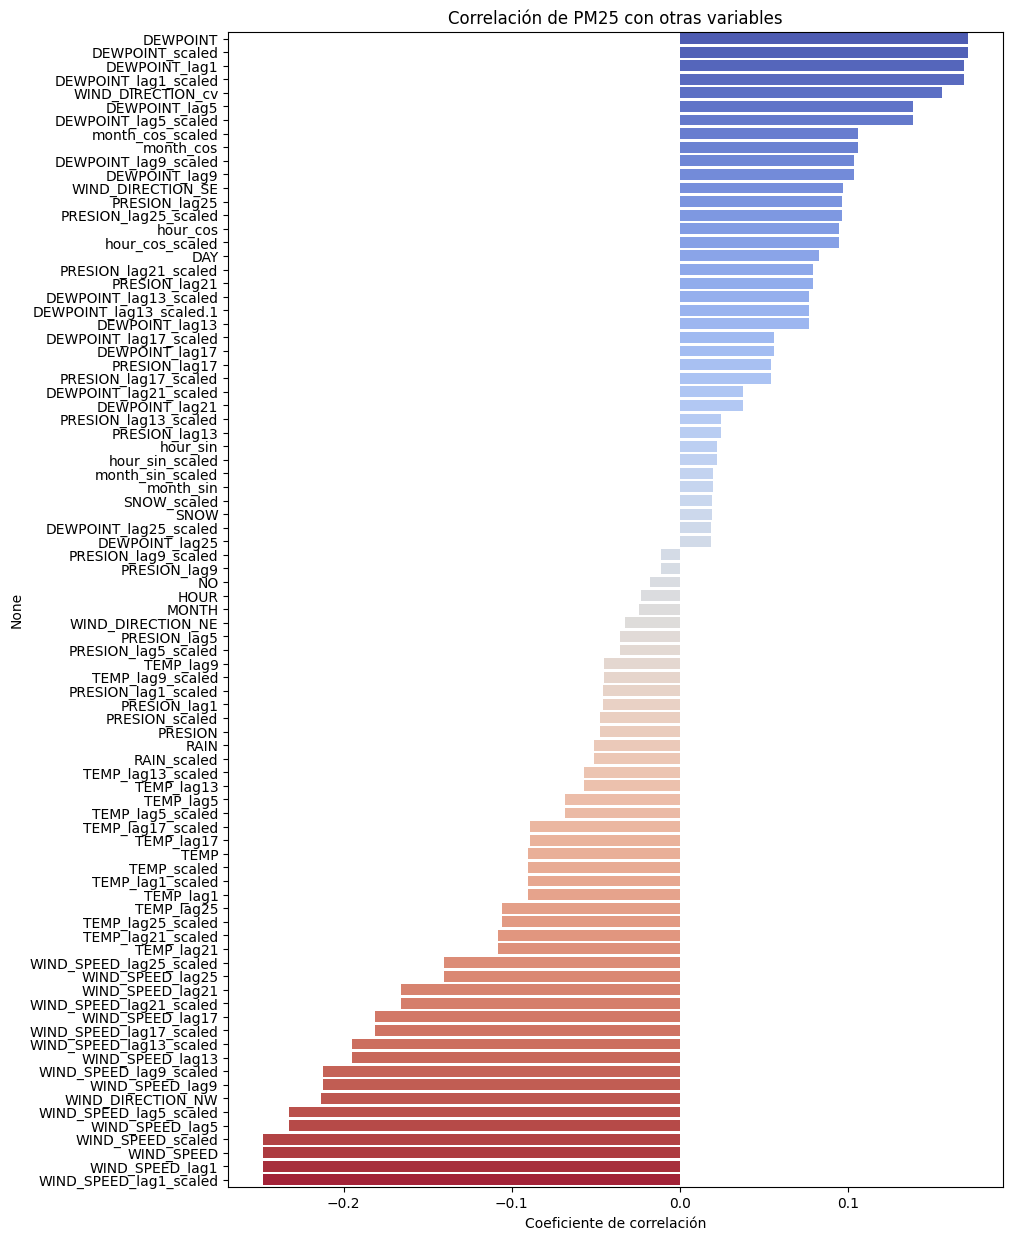

In [13]:
# 1. Seleccionar solo las columnas numéricas
# df_num = df_clean.select_dtypes(include=["float64", "int64"]) # Este código no fue útil ya que casi todas las variables son numéricas

# 1. Eliminar las columnas que no son para la regresión
#df_clean_num = df_clean.drop(columns=["NO", "YEAR", "MONTH", "DAY", "HOUR", "WIND_DIRECTION", "FECHA", "FECHA_SIN_H"])
df_clean_num = df_clean.drop(columns=[ "YEAR", "WIND_DIRECTION", "FECHA", "FECHA_SIN_H"])

# 2. Calcular la matriz de correlación
corr_matrix = df_clean_num.corr()

# 2. Extraer solo la correlación con PM25
corr_pm25 = corr_matrix["PM25"].drop("PM25")  # quitamos la correlación consigo misma

# 3. Ordenar las correlaciones de mayor a menor
corr_pm25_sorted = corr_pm25.sort_values(ascending=False)

# 4. Mostrar resultados
print(corr_pm25_sorted)

# 5. Graficar como barra horizontal
plt.figure(figsize=(10, 15))
sns.barplot(x=corr_pm25_sorted.values, y=corr_pm25_sorted.index, palette="coolwarm")
plt.title("Correlación de PM25 con otras variables")
plt.xlabel("Coeficiente de correlación")
plt.show()

# 3. Graficar con Seaborn
#plt.figure(figsize=(12, 8))  # ajusta tamaño según lo necesites
#sns.heatmap(corr_matrix,
#            annot=True,        # muestra valores numéricos
#            fmt=".2f",         # formato de decimales
#            cmap="coolwarm",   # paleta de colores
#            cbar=True)

#plt.title("Matriz de correlación de variables numéricas")
#plt.title("Matriz de correlación de variables numéricas", fontsize=14)
#plt.show()

#INTERPRETACIÓN: la variable pm2.5 tiene correlaciones:
# Negativas:
# -0.25 Wind_speed que puede hacer sentido porque dispesa las partículas
# -0.21 Wind_direction_NW

#Positivas:
# 0.17 con Dewpoint (rocío), aunque hubiera esperado una relación negativa
# 0.16 con Wind_Direction_cv

# Por su parte las variables con la "más alta correlación" con pm2.5, correlacionan más fuertemente entre ellas, como por ejemplo:
# Wind_speed  y Wind_direction_NW tienen una correlación de 0.36 :s o Wind_speed y Dewpoint -0.29.

In [19]:
# Expotar .csv
#DFs con los las correlaciones de PM25"
corr_pm25_sorted.to_csv("PRSA_data_correl_PM25.csv", sep='\t', encoding='utf-8', index=False, header=True)

In [18]:
#Buscamos el mejor lagueo
corr_ordenadas = corr_pm25.abs().sort_values(ascending=False)
print(corr_ordenadas)



WIND_SPEED_lag1           0.247817
WIND_SPEED_lag1_scaled    0.247817
WIND_SPEED                0.247782
WIND_SPEED_scaled         0.247782
WIND_SPEED_lag5           0.232563
                            ...   
DEWPOINT_lag25_scaled     0.018713
DEWPOINT_lag25            0.018713
NO                        0.017693
PRESION_lag9              0.011065
PRESION_lag9_scaled       0.011065
Name: PM25, Length: 85, dtype: float64


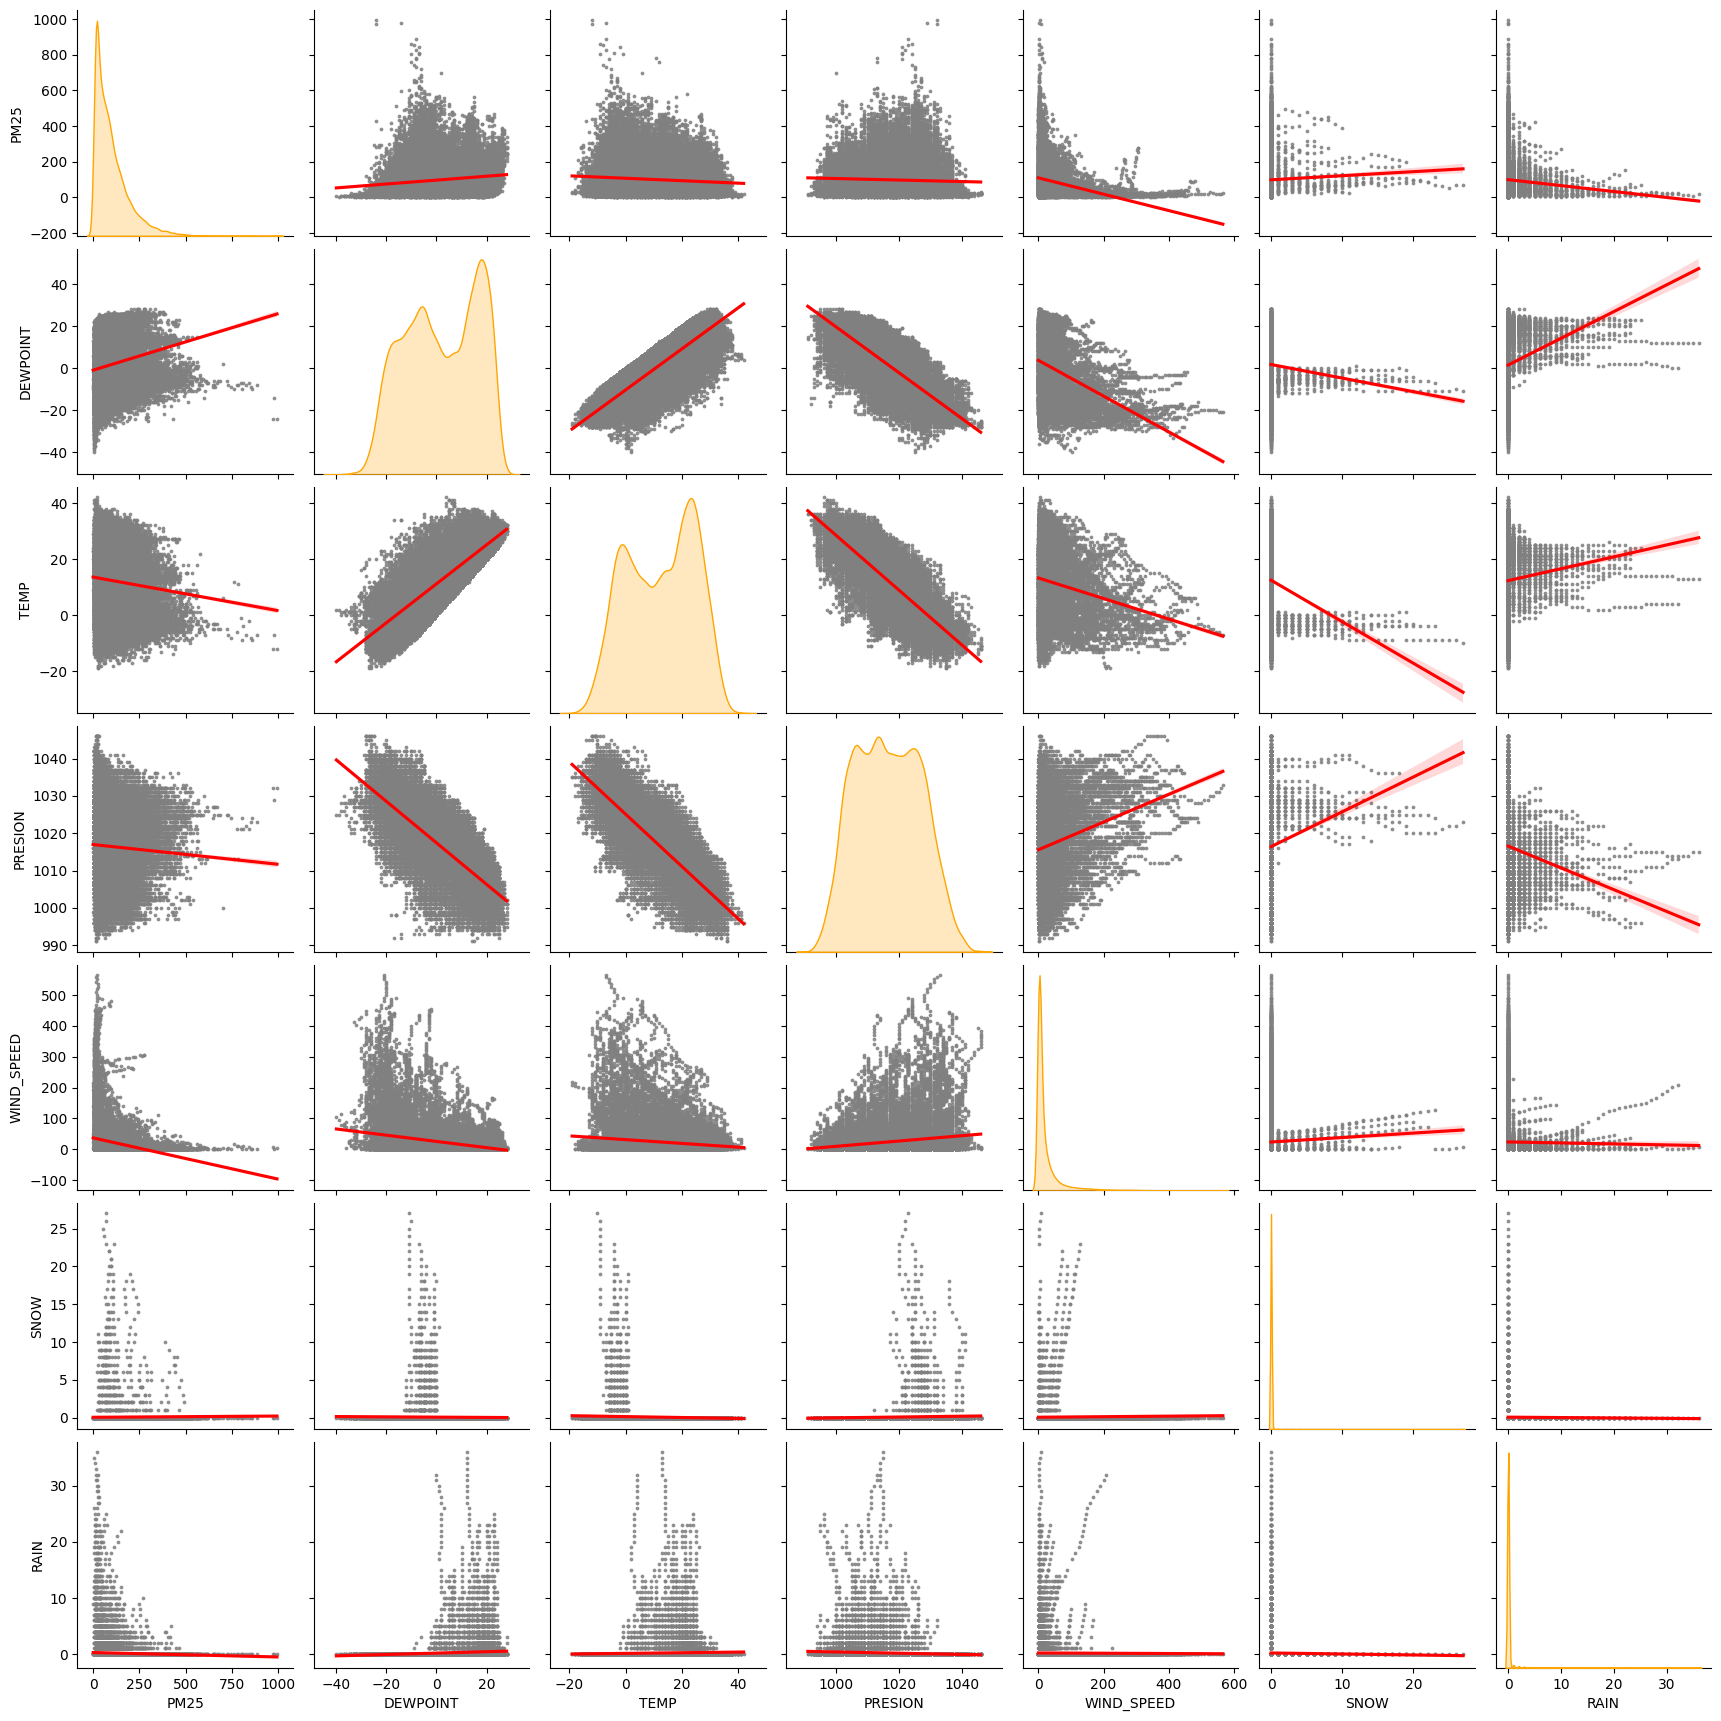

In [ ]:

# Crear DOS gráficos que muestren las correlaciones y distribuciones
#plt.figure(figsize=(10, 6))   # ajusta ancho y alto según

# Eliminar las columnas que no son para la regresión
df_clean_num = df_clean.drop(columns=["NO", "YEAR", "MONTH", "DAY", "HOUR", "WIND_DIRECTION", "FECHA", "FECHA_SIN_H"])

df_clean_num_noscaled = df_clean_num.drop(columns=["WIND_DIRECTION_NE", "WIND_DIRECTION_NW", "WIND_DIRECTION_SE", "WIND_DIRECTION_cv", "DEWPOINT_scaled" ,
                                                    "TEMP_scaled", "PRESION_scaled", "WIND_SPEED_scaled", "SNOW_scaled", "RAIN_scaled"
                                                  ])
sns.pairplot(
    df_clean_num_noscaled,
    diag_kws={"color": "orange"},
    diag_kind='kde',
    kind="reg",
    plot_kws={"scatter_kws":{"color":"grey", "s":3},  "line_kws": {"color": "red"}}, #aqui defines el tamaño de los puntos s:3
    )
plt.show()

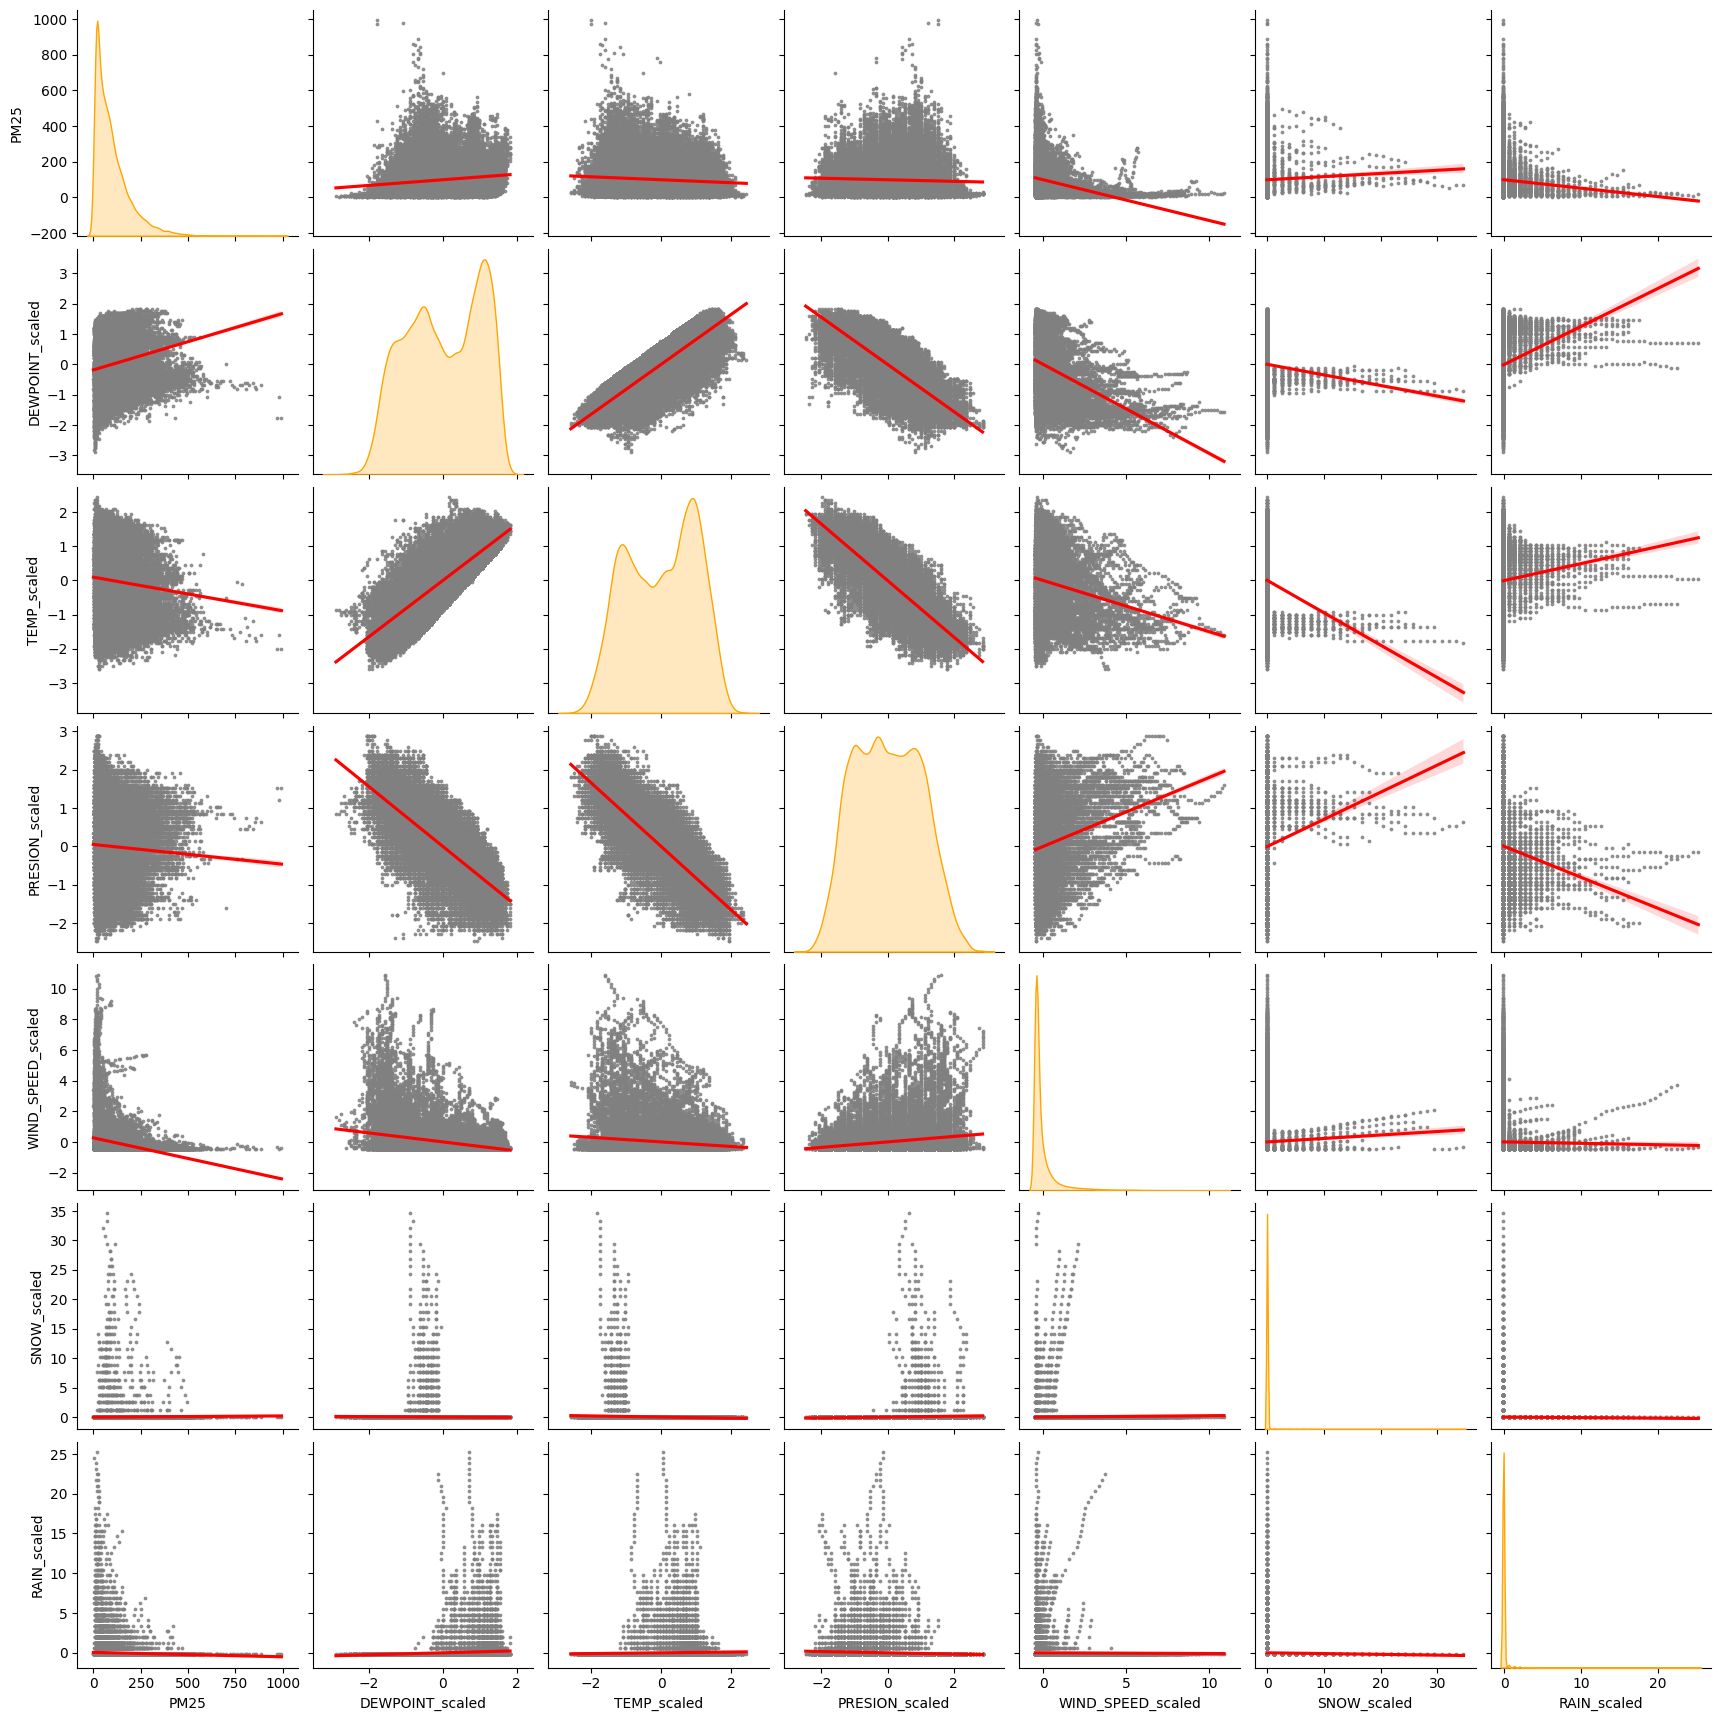

In [ ]:
# Eliminar las columnas que no son para la regresión
# Las gráficas de las columnas escaladas vs las que no lo están son iguales
df_clean_num = df_clean.drop(columns=["NO", "YEAR", "MONTH", "DAY", "HOUR", "WIND_DIRECTION", "FECHA", "FECHA_SIN_H"])

df_clean_num_scaled = df_clean_num.drop(columns=["DEWPOINT", "TEMP", "PRESION", "WIND_SPEED", "SNOW", "RAIN", "WIND_DIRECTION_NE", "WIND_DIRECTION_NW", "WIND_DIRECTION_SE", "WIND_DIRECTION_cv"])

sns.pairplot(
    df_clean_num_scaled,
    diag_kws={"color": "orange"},
    diag_kind='kde',
    kind="reg",
    plot_kws={"scatter_kws":{"color":"grey", "s":3},  "line_kws": {"color": "red"}}
    )
plt.show()

In [ ]:
#Modelo de Regresión Lineal

#from sklearn.linear_model import LinearRegression
#from sklearn.metrics import mean_squared_error, mean_absolute_error
#from sklearn.model_selection import train_test_split

y = df_clean["PM25"]
X = df_clean.drop(columns=["PM25", "WIND_DIRECTION", "FECHA", "FECHA_SIN_H" ])
# Poner y quitar las variables que necesites...
# 'NO', 'YEAR', 'MONTH','DAY', 'HOUR', 'DEWPOINT', 'TEMP', 'PRESION', 'WIND_DIRECTION','WIND_SPEED', 'SNOW', 'RAIN', 'FECHA', 'FECHA_SIN_H',
# 'WIND_DIRECTION_NE','WIND_DIRECTION_NW','WIND_DIRECTION_SE','WIND_DIRECTION_cv','DEWPOINT_scaled','TEMP_scaled', 'PRESION_scaled', 'WIND_SPEED_scaled','SNOW_scaled', 'RAIN_scaled',


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Ajusta el modelo con los datos de entrenamiento
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Genea valores estimados o predicciones
y_pred = lin_reg.predict(X_test)

#Evaluación del modelo
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R²:", r2)

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": lin_reg.coef_
})
print(coeficientes)

MSE: 6421.468643389553
MAE: 56.8965052977494
R²: 0.2712412524101818
             Variable  Coeficiente
0                  NO     0.171591
1                YEAR -1503.898598
2               MONTH  -126.553300
3                 DAY    -3.390416
4                HOUR     1.076990
5            DEWPOINT     4.376214
6                TEMP    -6.415276
7             PRESION    -1.578903
8          WIND_SPEED    -0.192987
9                SNOW    -1.369455
10               RAIN    -4.354325
11  WIND_DIRECTION_NE   -11.419236
12  WIND_DIRECTION_NW   -14.903831
13  WIND_DIRECTION_SE    13.444867
14  WIND_DIRECTION_cv    12.878201
15    DEWPOINT_scaled     0.303199
16        TEMP_scaled    -0.526919
17     PRESION_scaled    -0.153282
18  WIND_SPEED_scaled    -0.003890
19        SNOW_scaled    -1.758270
20        RAIN_scaled    -3.070430


In [ ]:
# Crear figura con tamaño controlado
plt.figure(figsize=(10, 6))   # ajusta ancho y alto según

g = sns.PairGrid(df_clean[["PM25", "DEWPOINT", "TEMP", "PRESION", "WIND_SPEED", "SNOW", "RAIN"]],
                 diag_sharey=False,
                 corner=True
                )
g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)
# llevar a la otra fase
<seaborn.axisgrid.PairGrid at 0x7f6811652f00>

SyntaxError: invalid syntax (3974239205.py, line 11)

Modelo en la base de datos PRSA_data_mice_scaled

Aquí va el código para los datos imputados con MICE

In [ ]:
# Importar la información  ya limpia y normalizada
df_imputed_mice = pd.read_csv("PRSA_data_mice.csv", sep='\t', encoding='utf-8')

In [ ]:
g = sns.PairGrid(df_clean[["PM25", "DEWPOINT", "TEMP", "PRESION", "WIND_SPEED", "SNOW", "RAIN"]],
                 diag_sharey=False,
                 corner=True
                )
g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)
# llevar a la otra fase
<seaborn.axisgrid.PairGrid at 0x7f6811652f00>


In [ ]:
#Modelo de Regresión Lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)


Se implementó un modelo de regresión lineal como línea base para evaluar el desempeño inicial. Este modelo permite establecer un punto de comparación para técnicas más complejas

In [ ]:
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lin_reg.coef_
})

print(coef_df)

Los coeficientes indican la relación entre las variables meteorológicas y la concentración de PM2.5. Coeficientes positivos implican un aumento en la contaminación al aumentar la variable, mientras que negativos sugieren una relación inversa.

In [ ]:
#Modelo de Regresión Ridge
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge MSE:", mean_squared_error(y_test, y_pred_ridge))
print("Ridge MAE:", mean_absolute_error(y_test, y_pred_ridge))


In [ ]:
Ridge penaliza el tamaño de los coeficientes reduciéndolos, pero sin llevarlos a cero. Esto ayuda a estabilizar el modelo en presencia de multicolinealidad, mejorando la generalización.

In [ ]:
#Modelos de regresión Lasso
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso MSE:", mean_squared_error(y_test, y_pred_lasso))
print("Lasso MAE:", mean_absolute_error(y_test, y_pred_lasso))


In [ ]:
#Variables eliminadas
coef_lasso = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lasso.coef_
})

print(coef_lasso)


Interpretación (importantísima)

Lasso introduce una penalización L1 que puede llevar ciertos coeficientes exactamente a cero, realizando una selección automática de variables. Esto simplifica el modelo y mejora su interpretabilidad, especialmente útil cuando existen variables irrelevantes o redundantes.

In [ ]:
# Comparación de modelos
results = pd.DataFrame({
    'Modelo': ['Linear', 'Ridge', 'Lasso'],
    'MSE': [
        mse,
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso)
    ],
    'MAE': [
        mae,
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso)
    ]
})

print(results)


# **Código No utilizado**

Mientras que la regresión lineal proporciona un modelo interpretable, su desempeño puede deteriorarse ante multicolinealidad. Ridge mejora la estabilidad del modelo, mientras que Lasso introduce parsimonia al eliminar variables irrelevantes, lo cual puede resultar en mejores modelos explicables en contextos reales.

<Figure size 1000x600 with 0 Axes>

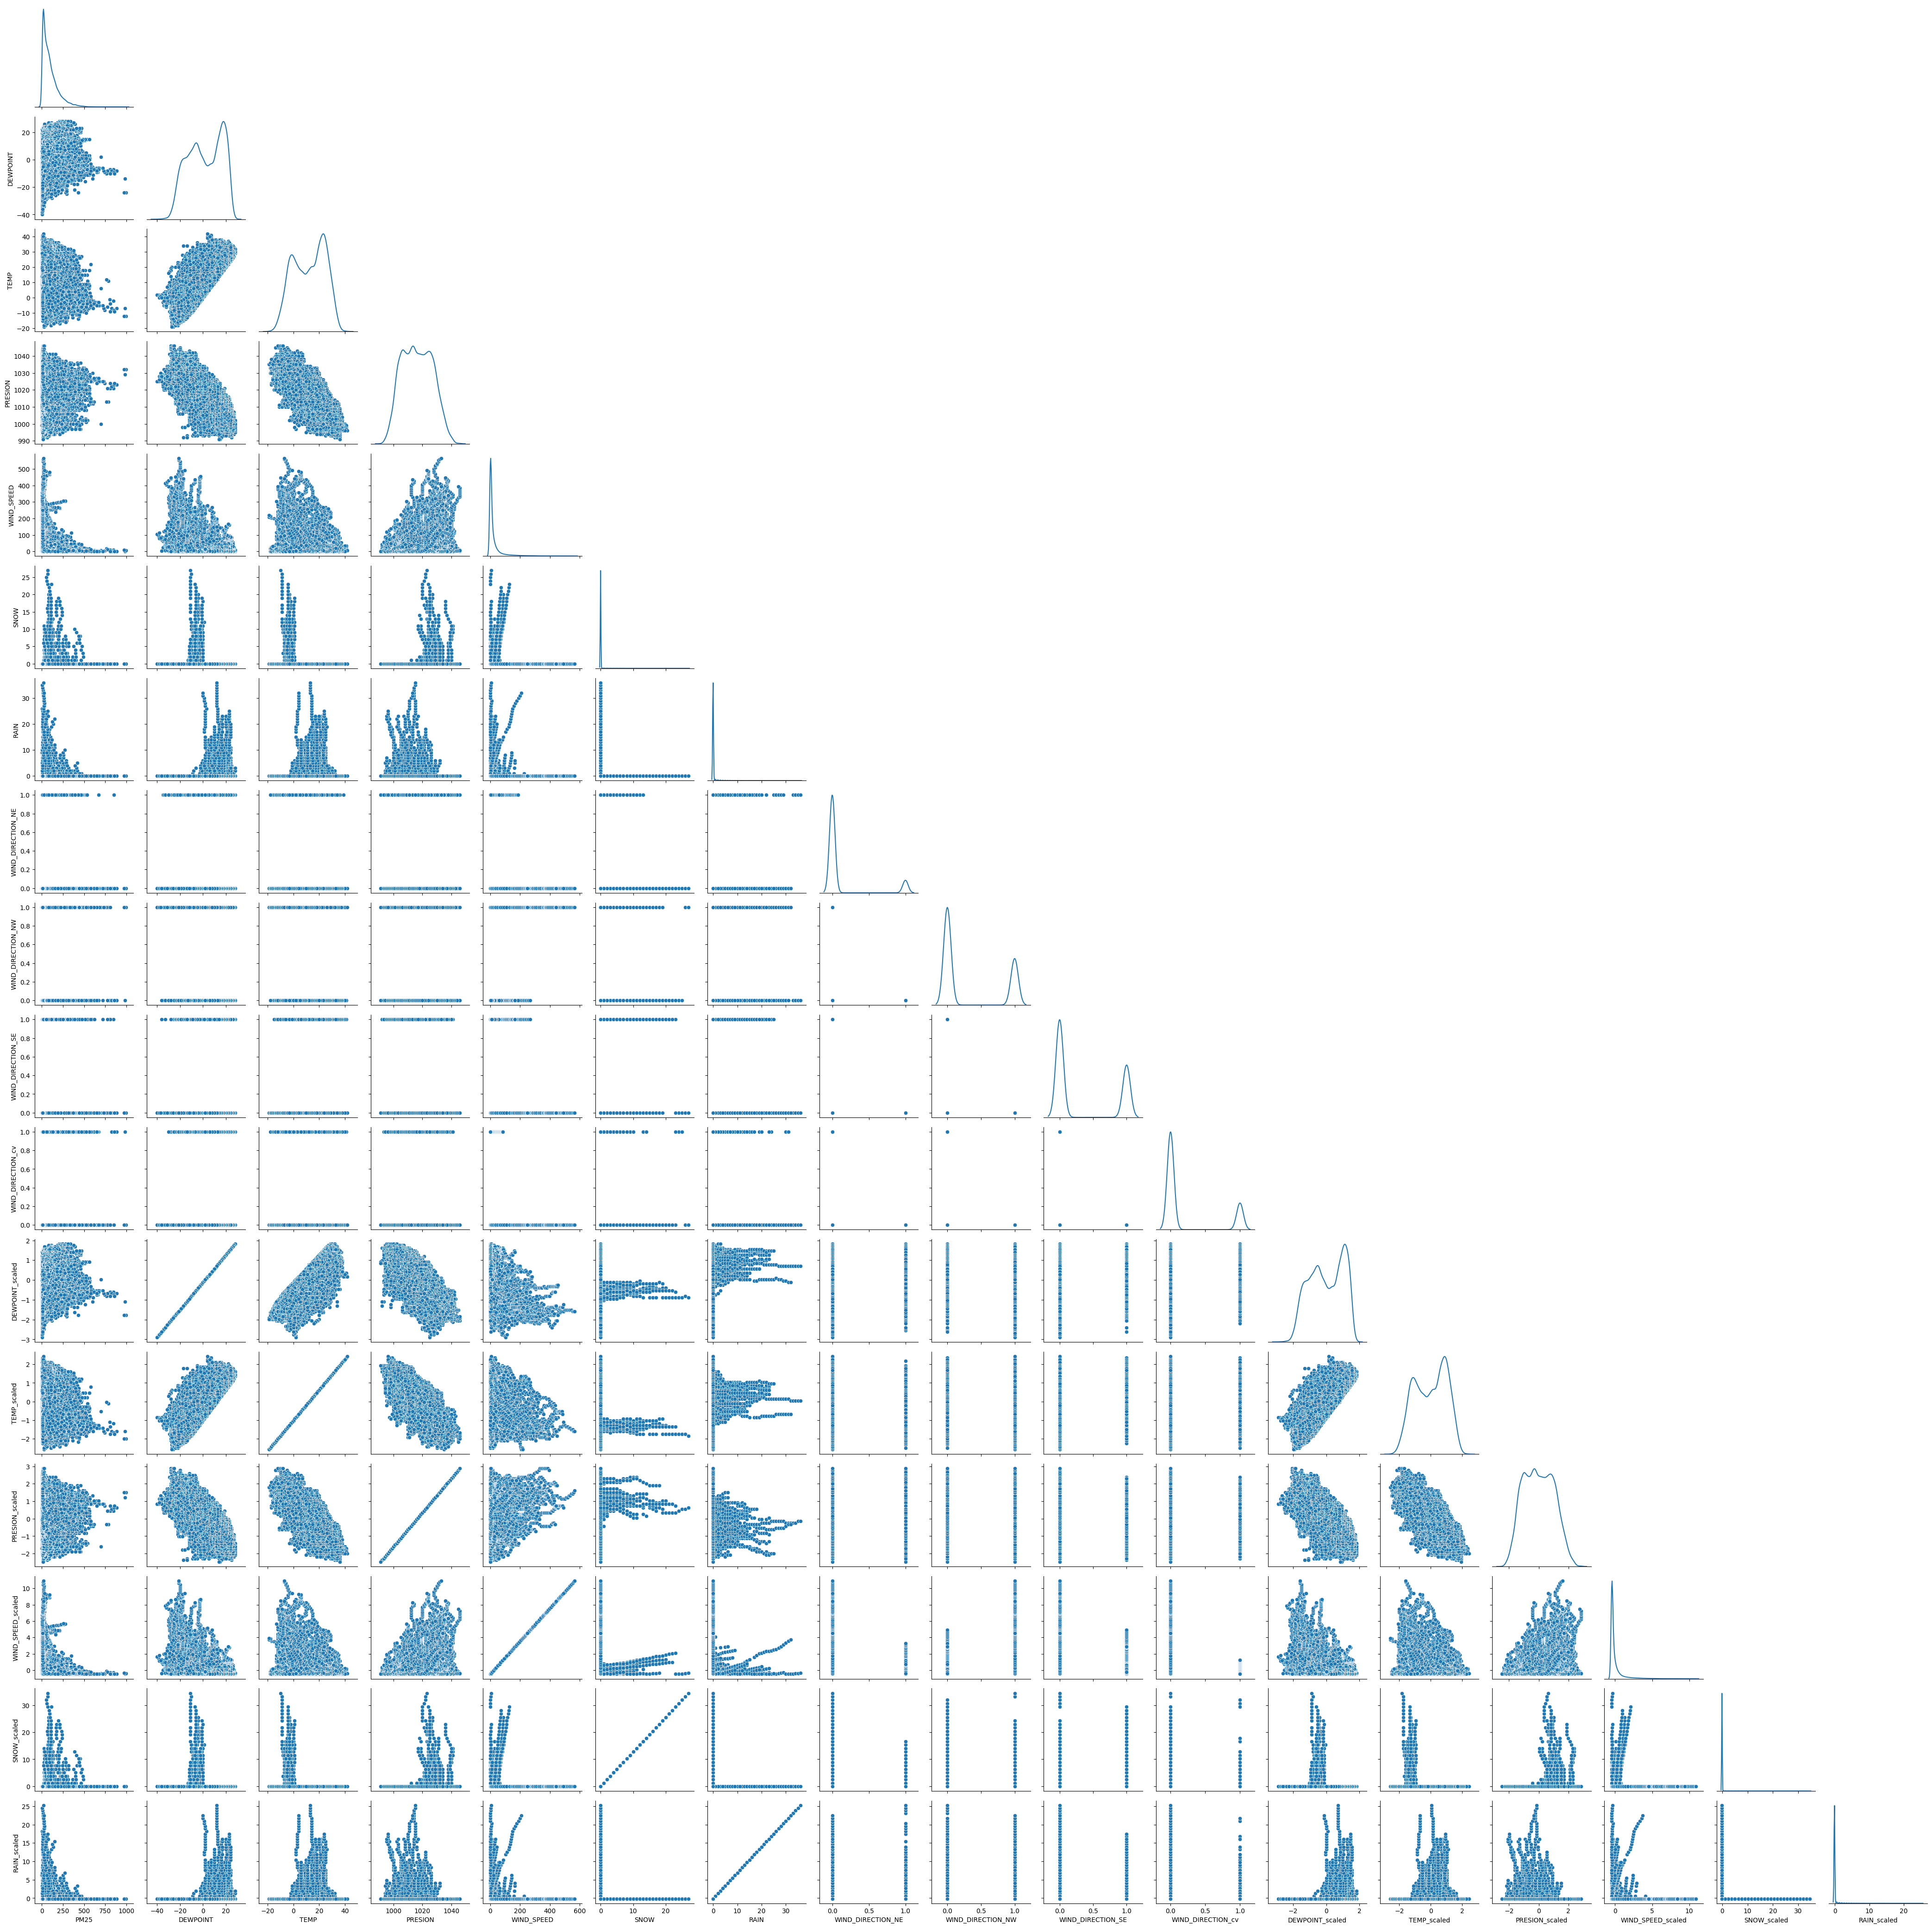

In [ ]:
# Crear figura con tamaño controlado
plt.figure(figsize=(10, 6))   # ajusta ancho y alto según

g = sns.PairGrid(
    df_clean[["PM25", "DEWPOINT", "TEMP", "PRESION", "WIND_SPEED", "SNOW", "RAIN", "WIND_DIRECTION_NE", "WIND_DIRECTION_NW", "WIND_DIRECTION_SE", "WIND_DIRECTION_cv",
                           "DEWPOINT_scaled", "TEMP_scaled", "PRESION_scaled", "WIND_SPEED_scaled", "SNOW_scaled", "RAIN_scaled"
              ]],
              diag_sharey=False,
              corner=True
                )
g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)

plt.show()